Trading Strategy

------FINAL--------

FINAL REPORT
Net Profit (USDT)             : 21,580.9991
Total Return (%)              : 215.8100
Total Trades Executed         : 80.0000
Win Rate (%)                  : 42.5000
Max Drawdown (%)              : -21.8774
Sharpe Ratio                  : 1.6655
Sortino Ratio                 : 1.0215
CAGR (%)                      : 46.6001
Total Transaction Fees        : 2,848.1718
Calmar Ratio                  : 2.1301


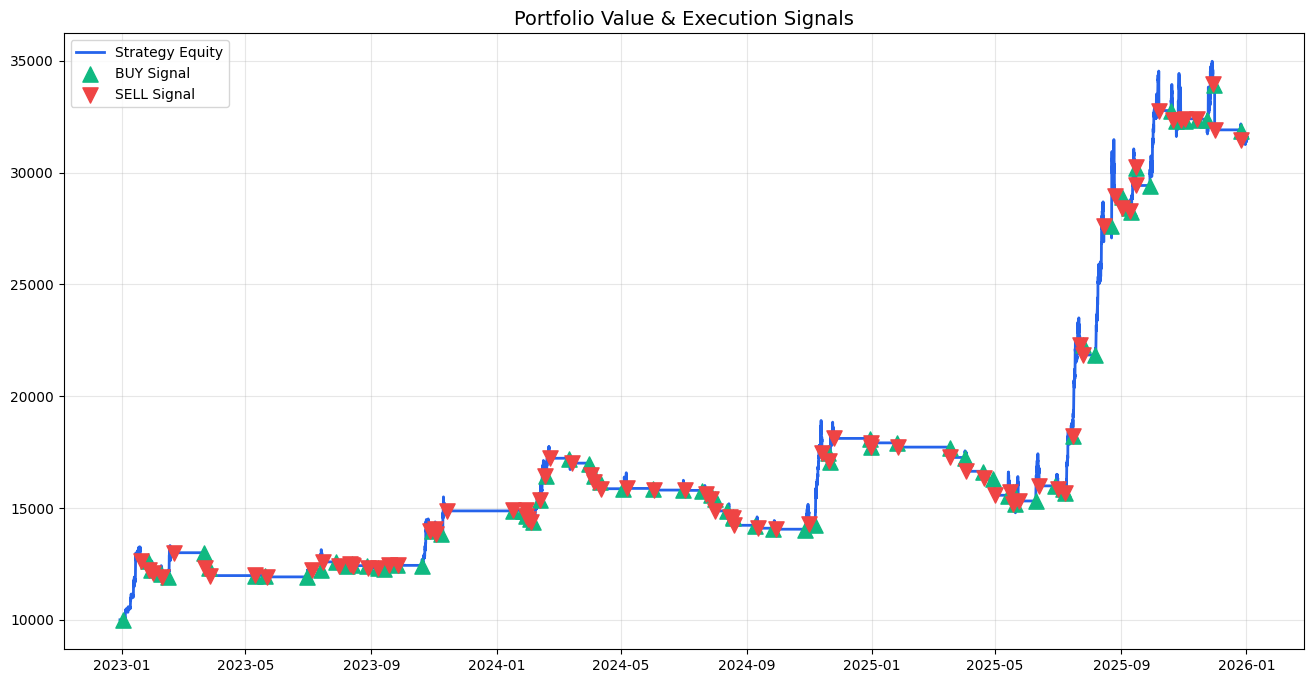

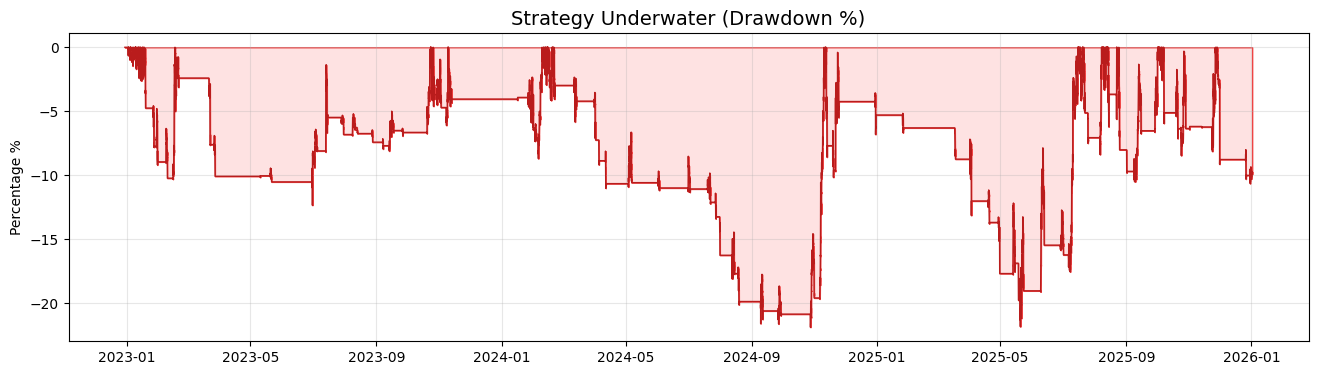

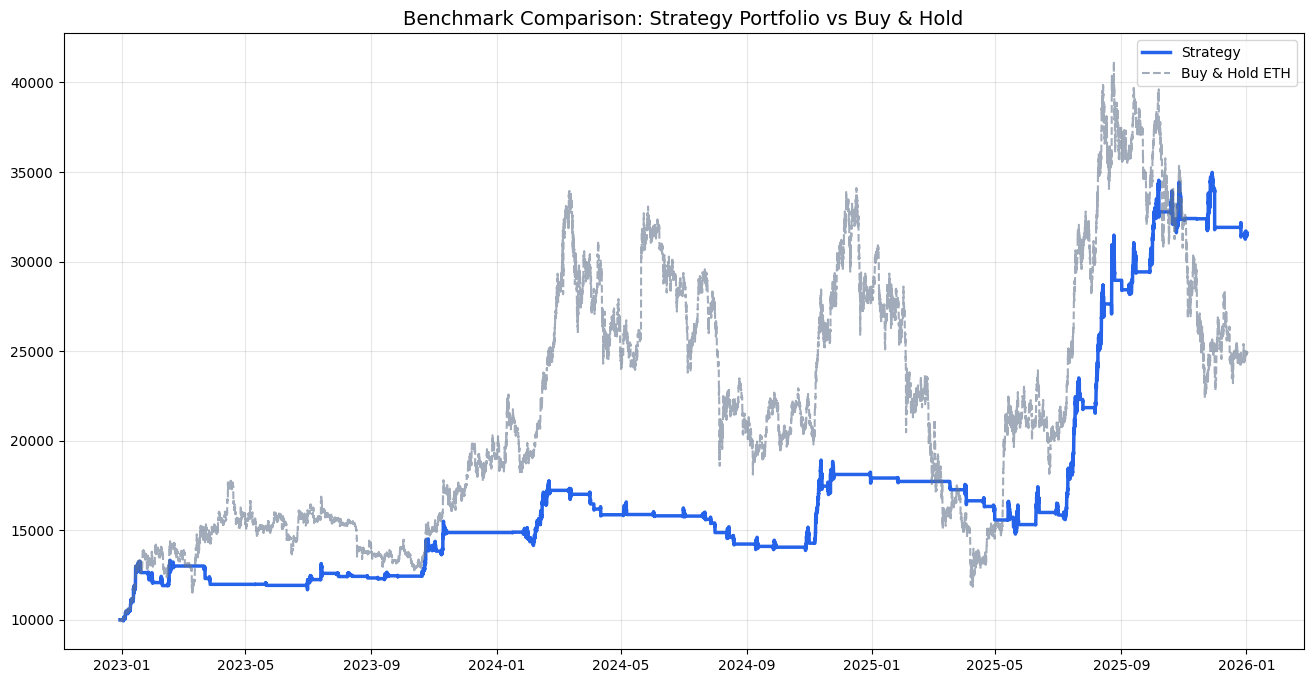

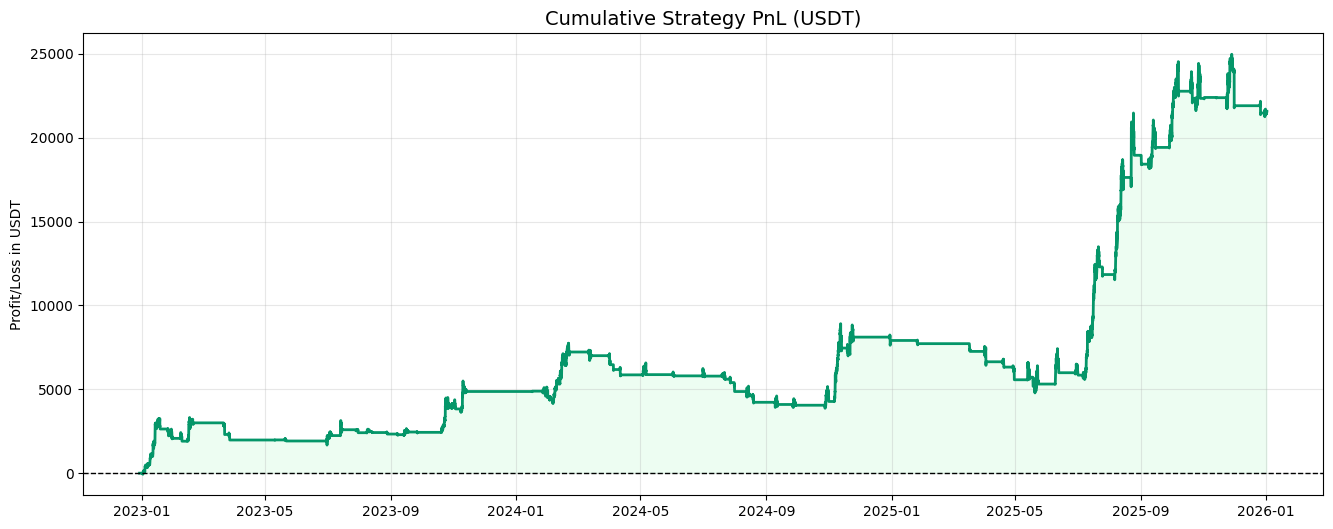

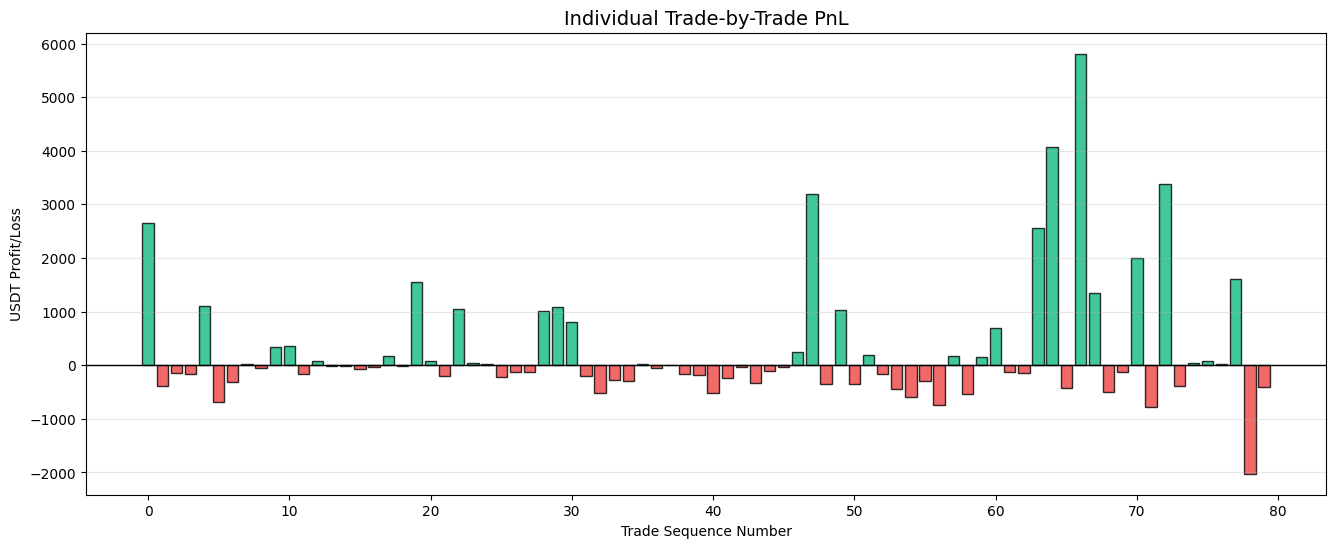

Total Realized PnL: 22,869.76 USDT
Average PnL per Trade: 285.87 USDT
Largest Winning Trade: 5,810.18 USDT
Largest Losing Trade: -2,024.18 USDT


In [2]:
print('------FINAL--------')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and Prepare Data
df = pd.read_csv('ETH-USDT_1h.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# 2. Indicator Functions
def calculate_adx(df, n=14):
    temp = df.copy()
    temp['tr'] = np.maximum(temp['high'] - temp['low'], 
                  np.maximum(abs(temp['high'] - temp['close'].shift(1)), 
                             abs(temp['low'] - temp['close'].shift(1))))
    temp['up'], temp['dn'] = temp['high'] - temp['high'].shift(1), temp['low'].shift(1) - temp['low']
    temp['+dm'] = np.where((temp['up'] > temp['dn']) & (temp['up'] > 0), temp['up'], 0)
    temp['-dm'] = np.where((temp['dn'] > temp['up']) & (temp['dn'] > 0), temp['dn'], 0)
    temp['tr_s'] = temp['tr'].rolling(window=n).sum()
    temp['+di'] = 100 * (temp['+dm'].rolling(window=n).sum() / (temp['tr_s'] + 1e-10))
    temp['-di'] = 100 * (temp['-dm'].rolling(window=n).sum() / (temp['tr_s'] + 1e-10))
    temp['dx'] = 100 * (abs(temp['+di'] - temp['-di']) / (temp['+di'] + temp['-di'] + 1e-10))
    return temp['dx'].rolling(window=n).mean()

def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    return 100 - (100 / (1 + (gain / (loss + 1e-10))))

# Apply Strategy Indicators
df['EMA_f'] = df['close'].ewm(span=20, adjust=False).mean()
df['EMA_s'] = df['close'].ewm(span=50, adjust=False).mean()
df['ADX'] = calculate_adx(df)
df['RSI'] = calculate_rsi(df['close'])
df['volume_ma'] = df['volume'].rolling(window=15).mean() 

# ==========================================
# 3. BACKTEST ENGINE
# ==========================================
def run_backtest_institutional(data, initial_capital=10000, fee_rate=0.001):
    cash = initial_capital
    qty = 0
    pos = 0
    total_fees = 0
    trades = []
    equity = []
    
    start_idx = data[['EMA_f', 'EMA_s', 'ADX', 'RSI', 'volume_ma']].first_valid_index() + 1
    
    for _ in range(start_idx):
        equity.append(initial_capital)
        
    for i in range(start_idx, len(data)):
        p = data['close'][i]
        vol = data['volume'][i]
        v_ma = data['volume_ma'][i]
        
        if pos == 0:
            if (data['EMA_f'][i-1] > data['EMA_s'][i-1]) and \
               (data['EMA_f'][i-2] <= data['EMA_s'][i-2]) and \
               data['ADX'][i] > 15 and \
               data['RSI'][i] < 75 and \
               vol > v_ma:
                
                fee = cash * fee_rate
                total_fees += fee
                cash -= fee
                qty = cash / p
                cash = 0
                pos = 1
                trades.append({'entry_t': data['timestamp'][i], 'entry_idx': i, 'entry_price': p})
        
        elif pos == 1:
            if (data['EMA_f'][i-1] < data['EMA_s'][i-1]) and \
               (data['EMA_f'][i-2] >= data['EMA_s'][i-2]):
                
                val = qty * p
                fee = val * fee_rate
                total_fees += fee
                cash = val - fee
                trades[-1].update({
                    'exit_t': data['timestamp'][i], 
                    'exit_idx': i, 
                    'exit_price': p,
                    'pnl': cash - (trades[-1]['entry_price'] * qty),
                    'dur': data['timestamp'][i] - trades[-1]['entry_t']
                })
                qty = 0
                pos = 0
        
        equity.append(cash + (qty * p))
        
    return pd.DataFrame(trades).dropna(), equity, total_fees

# Run Engine
trades_df, portfolio_equity, fees_paid = run_backtest_institutional(df)
df['portfolio_value'] = portfolio_equity
df['buy_hold'] = (10000 / df['close'].iloc[0]) * df['close']

# ==========================================
# 4. METRICS
# ==========================================
def calculate_institutional_metrics(res_df, trades, initial_cap, fees):
    returns = res_df['portfolio_value'].pct_change().dropna()
    n_year = 365 * 24 
    mean_ret = returns.mean()
    std_ret = returns.std()
    
    sharpe = (mean_ret / std_ret * np.sqrt(n_year)) if std_ret != 0 else 0
    downside_std = returns[returns < 0].std()
    sortino = (mean_ret / downside_std * np.sqrt(n_year)) if downside_std != 0 else 0
    
    res_df['cum_max'] = res_df['portfolio_value'].cummax()
    res_df['drawdown_pct'] = ((res_df['portfolio_value'] / res_df['cum_max']) - 1) * 100
    max_dd = res_df['drawdown_pct'].min()
    
    total_days = (res_df['timestamp'].iloc[-1] - res_df['timestamp'].iloc[0]).days
    years = total_days / 365.25
    final_val = res_df['portfolio_value'].iloc[-1]
    cagr = ((final_val / initial_cap) ** (1/years) - 1) * 100 if years > 0 else 0
    
    return {
        "Net Profit (USDT)": final_val - initial_cap,
        "Total Return (%)": ((final_val / initial_cap) - 1) * 100,
        "Total Trades Executed": len(trades),
        "Win Rate (%)": (trades['pnl'] > 0).mean() * 100 if len(trades) > 0 else 0,
        "Max Drawdown (%)": max_dd,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "CAGR (%)": cagr,
        "Total Transaction Fees": fees,
        "Calmar Ratio": abs(cagr / max_dd) if max_dd != 0 else 0
    }

results = calculate_institutional_metrics(df, trades_df, 10000, fees_paid)

# ==========================================
# 5. FINAL OUTPUT &  GRAPHS
# ==========================================
print("\n" + "="*45)
print("FINAL REPORT")
print("="*45)
for k, v in results.items():
    print(f"{k:30}: {v:,.4f}")
print("="*45)

# Plot 1: Portfolio Value & Buy/Sell Signals
plt.figure(figsize=(16, 8))
plt.plot(df['timestamp'], df['portfolio_value'], label='Strategy Equity', color='#2563eb', lw=2)
plt.scatter(df.loc[trades_df['entry_idx'], 'timestamp'], df.loc[trades_df['entry_idx'], 'portfolio_value'], 
            marker='^', color='#10b981', s=120, label='BUY Signal', zorder=5)
plt.scatter(df.loc[trades_df['exit_idx'], 'timestamp'], df.loc[trades_df['exit_idx'], 'portfolio_value'], 
            marker='v', color='#ef4444', s=120, label='SELL Signal', zorder=5)
plt.title('Portfolio Value & Execution Signals', fontsize=14)
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# Plot 2: Drawdowns
plt.figure(figsize=(16, 4))
plt.fill_between(df['timestamp'], df['drawdown_pct'], 0, color='#fee2e2', edgecolor='#ef4444')
plt.plot(df['timestamp'], df['drawdown_pct'], color='#b91c1c', lw=1)
plt.title('Strategy Underwater (Drawdown %)', fontsize=14)
plt.ylabel('Percentage %'); plt.grid(True, alpha=0.3)
plt.show()

# Plot 3: Strategy vs Benchmark (Buy and Hold)
plt.figure(figsize=(16, 8))
plt.plot(df['timestamp'], df['portfolio_value'], label='Strategy', color='#2563eb', lw=2.5)
plt.plot(df['timestamp'], df['buy_hold'], label='Buy & Hold ETH', color='#64748b', ls='--', alpha=0.6)
plt.title('Benchmark Comparison: Strategy Portfolio vs Buy & Hold', fontsize=14)
plt.yscale('linear') # Use 'log' if price action is extremely volatile
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()









# ==========================================
# 6. PnL VISUALIZATION
# ==========================================

# Calculate Cumulative PnL in dollars
df['cumulative_pnl'] = df['portfolio_value'] - 10000 

# Plot A: Cumulative PnL over time
plt.figure(figsize=(16, 6))
plt.plot(df['timestamp'], df['cumulative_pnl'], color='#059669', lw=2)
plt.fill_between(df['timestamp'], df['cumulative_pnl'], 0, 
                 where=(df['cumulative_pnl'] >= 0), color='#dcfce7', alpha=0.5)
plt.fill_between(df['timestamp'], df['cumulative_pnl'], 0, 
                 where=(df['cumulative_pnl'] < 0), color='#fee2e2', alpha=0.5)
plt.title('Cumulative Strategy PnL (USDT)', fontsize=14)
plt.ylabel('Profit/Loss in USDT')
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', lw=1, ls='--')
plt.show()

# Plot B: Individual Trade PnL (Bar Chart)
# This shows exactly how much each specific trade made or lost
plt.figure(figsize=(16, 6))
colors = ['#10b981' if x > 0 else '#ef4444' for x in trades_df['pnl']]
plt.bar(range(len(trades_df)), trades_df['pnl'], color=colors, edgecolor='black', alpha=0.8)
plt.axhline(0, color='black', lw=1)
plt.title('Individual Trade-by-Trade PnL', fontsize=14)
plt.xlabel('Trade Sequence Number')
plt.ylabel('USDT Profit/Loss')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# Print specific PnL stats
print(f"Total Realized PnL: {trades_df['pnl'].sum():,.2f} USDT")
print(f"Average PnL per Trade: {trades_df['pnl'].mean():,.2f} USDT")
print(f"Largest Winning Trade: {trades_df['pnl'].max():,.2f} USDT")
print(f"Largest Losing Trade: {trades_df['pnl'].min():,.2f} USDT")

trade logs

In [3]:
import pandas as pd
import numpy as np

# 1. Load Data
df = pd.read_csv('ETH-USDT_1h.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# 2. Indicators
def calculate_adx(df, n=14):
    temp = df.copy()
    temp['tr'] = np.maximum(temp['high'] - temp['low'], 
                  np.maximum(abs(temp['high'] - temp['close'].shift(1)), 
                             abs(temp['low'] - temp['close'].shift(1))))
    temp['up'], temp['dn'] = temp['high'] - temp['high'].shift(1), temp['low'].shift(1) - temp['low']
    temp['+dm'] = np.where((temp['up'] > temp['dn']) & (temp['up'] > 0), temp['up'], 0)
    temp['-dm'] = np.where((temp['dn'] > temp['up']) & (temp['dn'] > 0), temp['dn'], 0)
    temp['tr_s'] = temp['tr'].rolling(window=n).sum()
    temp['+di'] = 100 * (temp['+dm'].rolling(window=n).sum() / (temp['tr_s'] + 1e-10))
    temp['-di'] = 100 * (temp['-dm'].rolling(window=n).sum() / (temp['tr_s'] + 1e-10))
    temp['dx'] = 100 * (abs(temp['+di'] - temp['-di']) / (temp['+di'] + temp['-di'] + 1e-10))
    return temp['dx'].rolling(window=n).mean()

def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    return 100 - (100 / (1 + (gain / (loss + 1e-10))))

df['EMA_f'] = df['close'].ewm(span=20, adjust=False).mean()
df['EMA_s'] = df['close'].ewm(span=50, adjust=False).mean()
df['ADX'] = calculate_adx(df)
df['RSI'] = calculate_rsi(df['close'])
df['volume_ma'] = df['volume'].rolling(window=15).mean() 

# 3. Trade Log Generator Engine
def generate_trade_logs(data, initial_capital=10000, fee_rate=0.001):
    cash = initial_capital
    qty = 0
    pos = 0
    trade_id = 1
    trades = []
    
    start_idx = data[['EMA_f', 'EMA_s', 'ADX', 'RSI', 'volume_ma']].first_valid_index() + 1
    
    for i in range(start_idx, len(data)):
        p = data['close'][i]
        vol = data['volume'][i]
        v_ma = data['volume_ma'][i]
        t = data['timestamp'][i]
        
        # ENTRY LOGIC
        if pos == 0:
            if (data['EMA_f'][i-1] > data['EMA_s'][i-1]) and \
               (data['EMA_f'][i-2] <= data['EMA_s'][i-2]) and \
               data['ADX'][i] > 15 and \
               data['RSI'][i] < 75 and \
               vol > v_ma:
                
                fee = cash * fee_rate
                capital_before = cash
                cash -= fee
                qty = cash / p
                cash = 0
                pos = 1
                
                trades.append({
                    'Trade #': trade_id,
                    'Type': 'LONG',
                    'Entry Date': t,
                    'Entry Price (USDT)': round(p, 2),
                    'Quantity (ETH)': round(qty, 4),
                    'Capital Before (USDT)': round(capital_before, 2),
                    'Entry Fee (USDT)': round(fee, 2)
                })
        
        # EXIT LOGIC
        elif pos == 1:
            if (data['EMA_f'][i-1] < data['EMA_s'][i-1]) and \
               (data['EMA_f'][i-2] >= data['EMA_s'][i-2]):
                
                val = qty * p
                fee = val * fee_rate
                cash = val - fee
                
                entry_cost = trades[-1]['Capital Before (USDT)']
                net_pnl = cash - entry_cost
                pnl_pct = (net_pnl / entry_cost) * 100
                duration = t - trades[-1]['Entry Date']
                
                trades[-1].update({
                    'Exit Date': t,
                    'Exit Price (USDT)': round(p, 2),
                    'Exit Fee (USDT)': round(fee, 2),
                    'Capital After (USDT)': round(cash, 2),
                    'Net PnL (USDT)': round(net_pnl, 2),
                    'Return (%)': round(pnl_pct, 2),
                    'Duration': duration,
                    'Exit Reason': 'EMA Bearish Cross'
                })
                
                qty = 0
                pos = 0
                trade_id += 1
                
    logs_df = pd.DataFrame(trades)
    return logs_df

# Generate Trade Logs
trade_logs = generate_trade_logs(df)

# Display First 10 Trade Logs
print("="*80)
print("TRADE LOGS SUMMARY (First 10 Executed Trades)")
print("="*80)
cols_to_show = ['Trade #', 'Entry Date', 'Exit Date', 'Entry Price (USDT)', 'Exit Price (USDT)', 'Net PnL (USDT)', 'Return (%)', 'Duration']
print(trade_logs[cols_to_show].head(10).to_string(index=False))

# Export Logs to CSV
trade_logs.to_csv('ETH_USDT_Trade_Logs.csv', index=False)
print("\n[+] Full trade logs exported successfully to 'ETH_USDT_Trade_Logs.csv'")

TRADE LOGS SUMMARY (First 10 Executed Trades)
 Trade #          Entry Date           Exit Date  Entry Price (USDT)  Exit Price (USDT)  Net PnL (USDT)  Return (%)         Duration
       1 2023-01-01 19:00:00 2023-01-18 20:00:00             1201.78            1521.38         2634.08       26.34 17 days 01:00:00
       2 2023-01-26 06:00:00 2023-01-27 03:00:00             1613.23            1565.73         -396.51       -3.14  0 days 21:00:00
       3 2023-01-29 09:00:00 2023-01-30 16:00:00             1600.99            1583.11         -160.86       -1.31  1 days 07:00:00
       4 2023-02-07 18:00:00 2023-02-09 03:00:00             1638.78            1619.05         -169.25       -1.40  1 days 09:00:00
       5 2023-02-14 16:00:00 2023-02-20 03:00:00             1539.70            1684.38         1092.87        9.18  5 days 11:00:00
       6 2023-03-21 15:00:00 2023-03-22 21:00:00             1812.55            1719.46         -692.34       -5.33  1 days 06:00:00
       7 2023-03-26 14: